# Autómatas de Células de McCulloch-Pitts (MP)
---

* El modelo de McCulloch-Pitts, o MP, es uno de los primeros modelos de neurona
* El MP es un modelo matemático de neurona que explora si los modelos neuronales pueden implementar operaciones lógicas y, en caso afirmativo, cómo
* Fue descrito por primera vez en 1943 por Warren S. McCulloch y Walter Pitts en el artículo "Un cálculo lógico de las ideas inmanentes en la actividad nerviosa"
* Proviene del estudio de la estructura de las neuronas humanas y sus conexiones
* Constituyeron el primer paso para lo que hoy se denomina RNA
* Están constituidos por un conjunto de células interconectadas entre sí 

## Neuronas MP

* La neurona de McCulloch-Pitts, o unidad MP, se conoce actualmente como modelo de puerta de umbral lineal
* Las unidades MP tienen varias entradas $\{x_1, ..., x_n\}$, cuyos valores pueden ser $\{0, 1\}$
* Estas entradas se suman linealmente para medir la activación de la unidad
* Existe un umbral. Si el nivel de activación supera este umbral, la unidad emite un 1; de lo contrario, emite un 0.
* La neurona MP se puede visualizar de la siguiente manera:

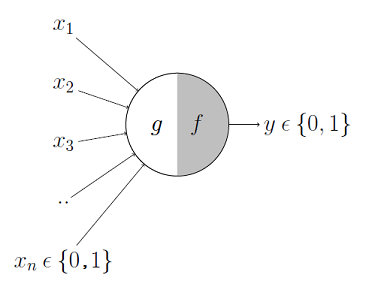

In [22]:
class MPNeuron():
    """A McCulloch Pitts neuron model."""
 
    def __init__(self, bias=0, umbral=0):
        self.bias = bias
        self.umbral = umbral
 
    def fire(self, entradas):
        activacion = sum(entradas) + self.bias
        return self.limite(activacion)

    def limite(self, activacion): 
        return int(activacion > self.umbral)

In [23]:
mp = MPNeuron()

In [24]:
inputs = [1, 1]
mp.fire(inputs)

1

In [25]:
inputs = [1, 0, 1]
mp.fire(inputs)

1

In [26]:
mp = MPNeuron(umbral=1)

In [27]:
inputs = [1, 0, 0]
mp.fire(inputs)

0

## Calculando AND

In [28]:
# Set up the inputs and expected outputs for logical 'AND'
input_pairs = [(0,0), (0,1), (1,0), (1,1)]
expected_outputs = [0, 0, 0, 1]

In [29]:
# Check out inputs and expected outputs
print("Input Pair\t Target Output")
for input_pair, expected_output in zip(input_pairs, expected_outputs):
    print(str(input_pair) + "\t\t " + str(expected_output))

Input Pair	 Target Output
(0, 0)		 0
(0, 1)		 0
(1, 0)		 0
(1, 1)		 1


In [30]:
mp_and = MPNeuron(0, 1)

In [31]:
# See if our MP neuron can calculate logical 'AND'
print("Input Pair\t Calculated Output\t Target Output")
for input_pair, expected_output in zip(input_pairs, expected_outputs):
    out = mp_and.fire(input_pair)
    print(str(input_pair) + "\t\t " + str(out) + "\t\t\t "+ str(expected_output))

Input Pair	 Calculated Output	 Target Output
(0, 0)		 0			 0
(0, 1)		 0			 0
(1, 0)		 0			 0
(1, 1)		 1			 1


## Calculando OR

In [32]:
# Set up the inputs and expected outputs for logical 'AND'
input_pairs = [(0,0), (0,1), (1,0), (1,1)]
expected_outputs = [0, 1, 1, 1]

In [33]:
# Check out inputs and expected outputs
print("Input Pair\t Target Output")
for input_pair, expected_output in zip(input_pairs, expected_outputs):
    print(str(input_pair) + "\t\t " + str(expected_output))

Input Pair	 Target Output
(0, 0)		 0
(0, 1)		 1
(1, 0)		 1
(1, 1)		 1


In [34]:
mp_or = MPNeuron(1, 1)

In [35]:
# See if our MP neuron can calculate logical 'AND'
print("Input Pair\t Calculated Output\t Target Output")
for input_pair, expected_output in zip(input_pairs, expected_outputs):
    out = mp_or.fire(input_pair)
    print(str(input_pair) + "\t\t " + str(out) + "\t\t\t "+ str(expected_output))

Input Pair	 Calculated Output	 Target Output
(0, 0)		 0			 0
(0, 1)		 1			 1
(1, 0)		 1			 1
(1, 1)		 1			 1


## Extendiendo la neurona MP

* La descripción anterior representa el modelo neuronal más simple posible
* A partir de aquí, imaginamos agregarle mayor complejidad
* En particular, la neurona MP original también incluye la conceptualización de neuronas excitadoras e inhibidoras.
* Podemos implementar esto mediante el concepto de pesos.
* En el caso de la neurona MP, recordemos que las entradas pueden ser $\{0, 1\}$
* Para implementar entradas excitadoras e inhibidoras, podemos usar pesos de $\{-1, 0, 1\}$

In [36]:
class MPNeuron():
    """A McCulloch Pitts neuron model, with weights."""
 
    def __init__(self, pesos, bias=0, umbral=0):
        self.pesos = pesos
        self.bias = bias
        self.umbral = umbral
 
    def fire(self, entradas):
        activacion = sum([i * w for (i, w) in zip(entradas, self.pesos)])
        return self.limite(activacion + self.bias)
    
    def limite(self, activacion):
        return int(activacion > self.umbral)

In [37]:
mp = MPNeuron([1, -1])

In [38]:
inputs = [1, 1]
mp.fire(inputs)

0

## Limitaciones de la unidad MP

* Valores booleanos: todas las entradas y salidas son 0 o 1, lo cual es limitante
* Podemos establecer, o intentar aprender, el valor umbral b, pero su rango es limitado
* No existe un procedimiento de entrenamiento claro para encontrar el modelo específico que necesitamos para lograr un objetivo determinado.